# Trabajo Práctico 4: Aprendizaje No-Supervisado

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import time
import torch
import pandas as pd
import seaborn as sns
%load_ext autoreload
%autoreload 2
from src.utils import print_images, stratified_split, set_seed
from src.PCA import standardize_data, pca_fit, pca_transform, pca_inverse_transform
from src.AE import AE, Trainer, get_dataloaders

RANDOM_SEED = 1973

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## EDA

In [3]:
df = pd.read_csv("data/raw/fashion_mnist_subset.csv")
y = df["label"]
X = df.drop(columns=["label"])

# Verificar shape
print("X shape:", X.shape)  
print("y shape:", y.shape)
print("Labels:", np.unique(y))

np.save("data/raw/X_images.npy", X)
np.save("data/raw/y_labels.npy", y)

X shape: (25000, 784)
y shape: (25000,)
Labels: [0 1 2 3 4 5 6 7 8 9]


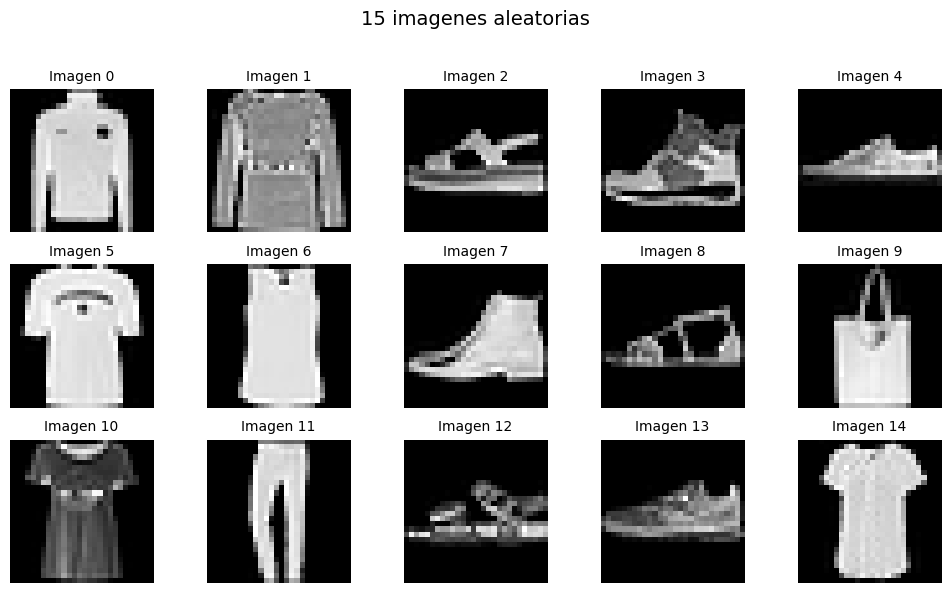

In [79]:
X = np.load("data/raw/X_images.npy")
y = np.load("data/raw/y_labels.npy")
N = 15

print_images(N, X, f"{N} imagenes aleatorias",RANDOM_SEED)

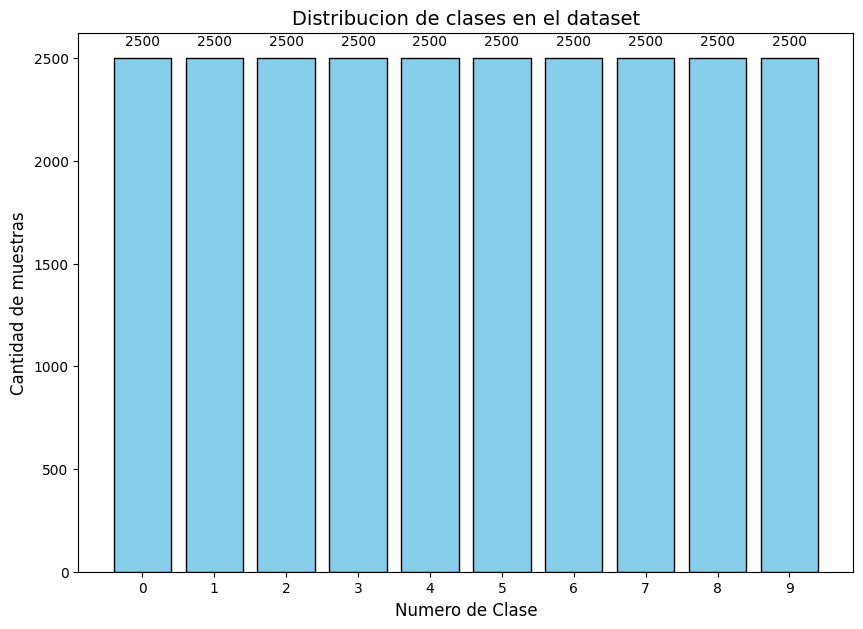

In [5]:
# Grafico de distribucion de clases

clases, conteos = np.unique(y, return_counts=True)

plt.figure(figsize=(10, 7))

bars = plt.bar(clases, conteos, color='skyblue', edgecolor='black')

plt.title('Distribucion de clases en el dataset', fontsize=14)
plt.xlabel('Numero de Clase', fontsize=12)
plt.ylabel('Cantidad de muestras', fontsize=12)

plt.xticks(clases)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, int(yval), 
             ha='center', va='bottom', fontsize=10)

plt.show()

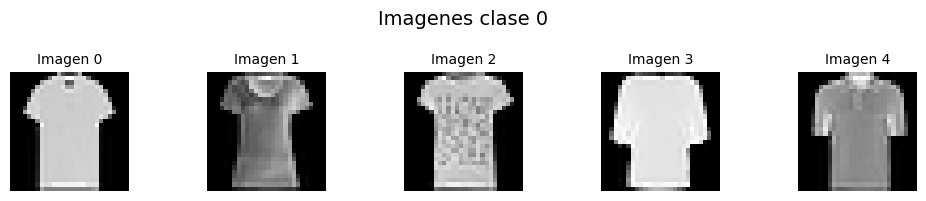

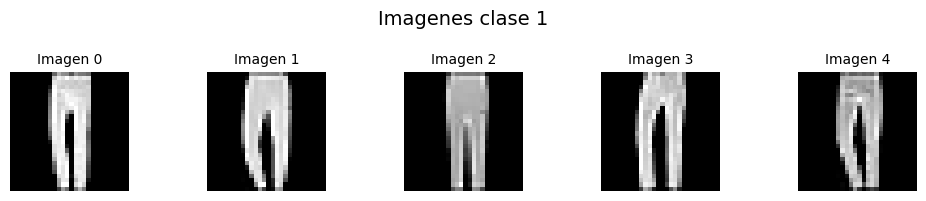

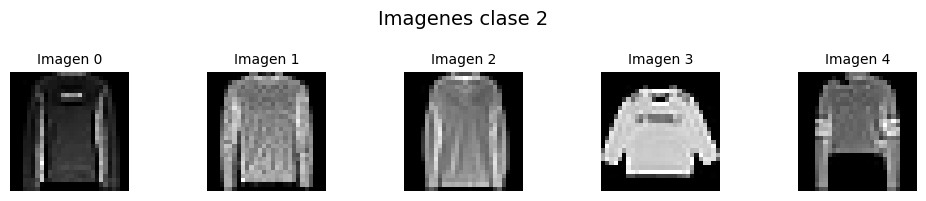

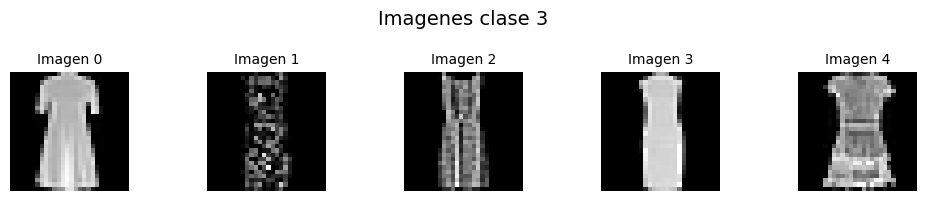

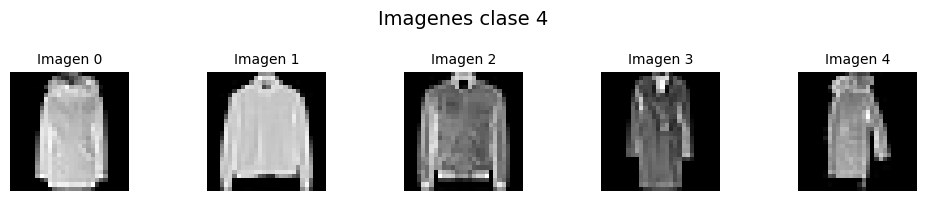

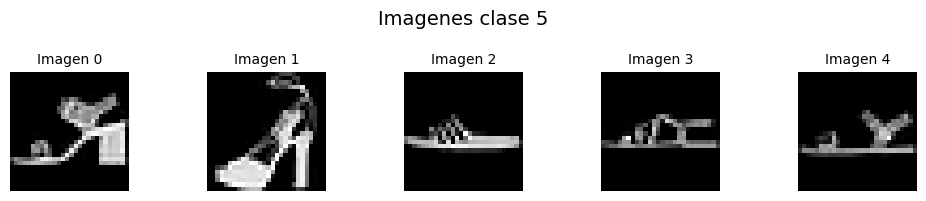

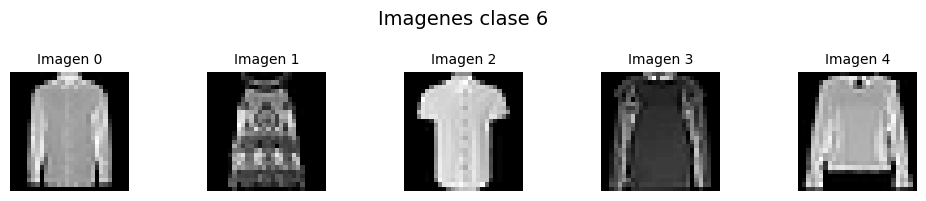

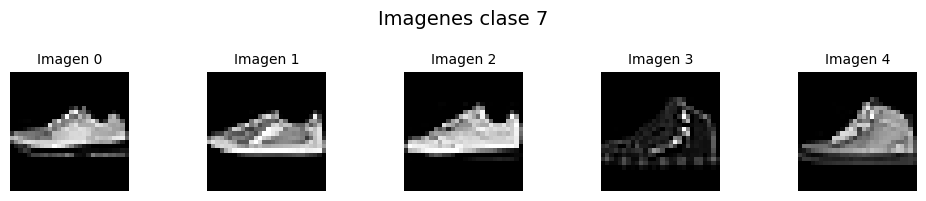

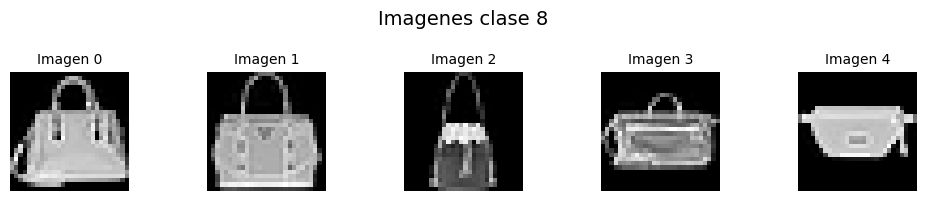

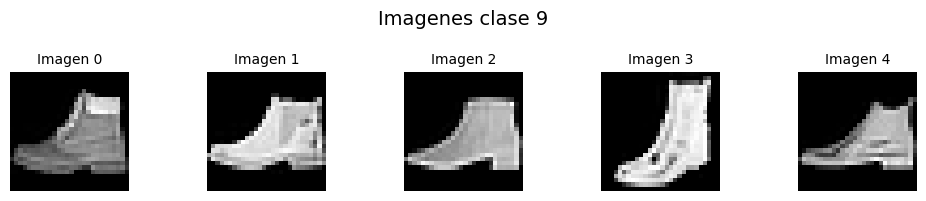

In [80]:
for i in np.unique(y):
    class_images = X[y == i]
    print_images(
        5,
        class_images,
        random_seed=RANDOM_SEED+i,
        title=f"Imagenes clase {i}"
    )

In [7]:
# Hago un split 80/20 manteniendo la misma proporcion de cada clase en train y validation

X_train, X_val, y_train, y_val = stratified_split(X, y, 0.8)

print(f"Train size: {len(X_train)}")
print(f"Val size: {len(X_val)}")

for label in np.unique(y):
    train_count = np.sum(y_train == label)
    val_count = np.sum(y_val == label)

    print(
        f"Clase {label}: "
        f"train={train_count}/{len(y_train)} ({train_count / len(y_train):.1%}), "
        f"val={val_count}/{len(y_val)} ({val_count / len(y_val):.1%})"
    )

np.save("data/preprocessed/X_train.npy", X_train)
np.save("data/preprocessed/X_val.npy", X_val)
np.save("data/preprocessed/y_train.npy", y_train)
np.save("data/preprocessed/y_val.npy", y_val)

Train size: 20000
Val size: 5000
Clase 0: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 1: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 2: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 3: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 4: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 5: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 6: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 7: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 8: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 9: train=2000/20000 (10.0%), val=500/5000 (10.0%)


## Reducción de dimensionalidad

### PCA

In [ ]:
# Estandarizo losa datos de train
X_train_std, mean_train, std_train = standardize_data(X_train)

# fiteo y aplico PCA a los datos de train
components_train, variance_ratio = pca_fit(X_train_std)
n_comp = 100 # Tomo un numero de componentes arbitrario para checkear que funcione
X_train_pca = pca_transform(X_train_std, components_train, n_comp)

# Estandarizo los datos de validation usando la media y std del train
X_val_std, _, _ = standardize_data(X_val, mean=mean_train, std=std_train)
X_val_pca = pca_transform(X_val_std, components_train, n_comp)

print("Verificacion de Dimensiones")

# Chequeo de los datos originales
print(f"Dimensiones de X_train original: {X_train.shape}")
print(f"Dimensiones de X_val original: {X_val.shape}")

# Chequeo de los datos estandarizados
print(f"Dimensiones de X_train_std: {X_train_std.shape}")
print(f"Dimensiones de X_val_std: {X_val_std.shape}")

# Chequeo de los componentes obtenidos por SVD
print(f"Dimensiones de matriz Vt: {components_train.shape}")

# Chequeo de los datos reducidos
print(f"Dimensiones de X_train_pca: {X_train_pca.shape}")
print(f"Dimensiones de X_val_pca: {X_val_pca.shape}")

Verificacion de Dimensiones
Dimensiones de X_train original: (20000, 784)
Dimensiones de X_val original: (5000, 784)
Dimensiones de X_train_std: (20000, 784)
Dimensiones de X_val_std: (5000, 784)
Dimensiones de matriz Vt: (784, 784)
Dimensiones de X_train_pca: (20000, 100)
Dimensiones de X_val_pca: (5000, 100)


Numero de componentes necesarios para explicar el 90% de la varianza: 134


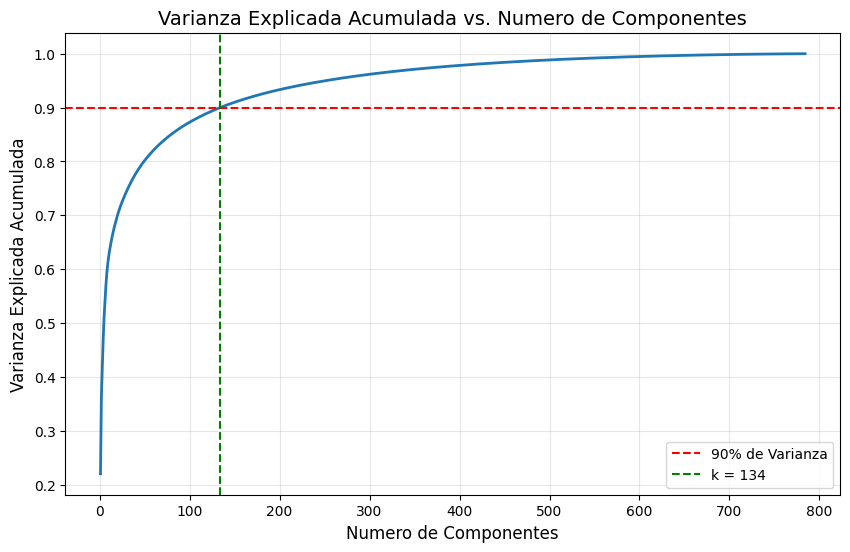

In [25]:
# varianza acumulada de los componentes
cumulative_variance = np.cumsum(variance_ratio)

# busco el k para tener el 90% de varianza explicada
k_90 = np.argmax(cumulative_variance >= 0.9) + 1
print(f"Numero de componentes necesarios para explicar el 90% de la varianza: {k_90}")


plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, linewidth=2)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% de Varianza')
plt.axvline(x=k_90, color='g', linestyle='--', label=f'k = {k_90}')
plt.title('Varianza Explicada Acumulada vs. Numero de Componentes', fontsize=14)
plt.xlabel('Numero de Componentes', fontsize=12)
plt.ylabel('Varianza Explicada Acumulada', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

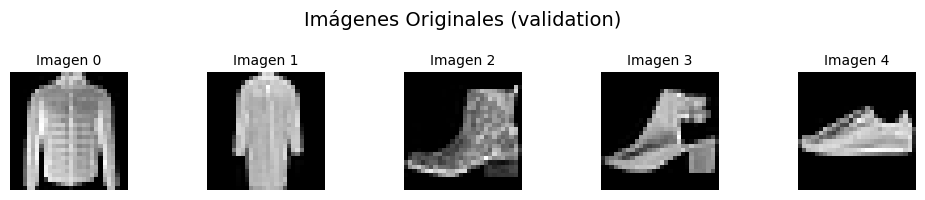

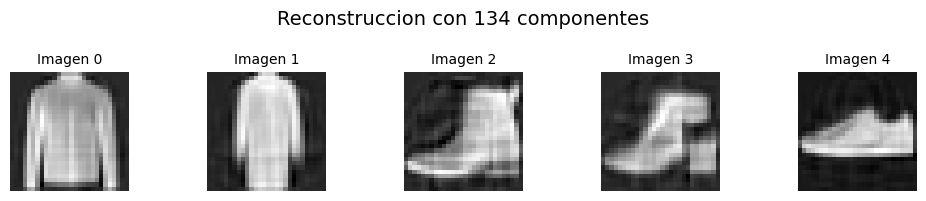

In [83]:
# transformo los datos de validation usando los k_90 componentes necesarios para explicar el 90% de la varianza
X_val_pca_90 = pca_transform(X_val_std, components_train, k_90)

# reconstruyo las imagenes a partir de esos k_90 componentes
X_val_reconstructed = pca_inverse_transform(X_val_pca_90, components_train, k_90, mean_train, std_train)

print_images(5, X_val, random_seed=RANDOM_SEED, title="Imágenes Originales (validation)")
print_images(5, X_val_reconstructed, random_seed=RANDOM_SEED, title=f"Reconstruccion con {k_90} componentes")

### Autoencoder deterministico (AE)

Early Stopping en epoch 98!
--------------------------------------------------
Entrenamiento finalizado.
El modelo restauró sus pesos a la epoch 83.
Validation Loss final retenida: 0.1374
--------------------------------------------------


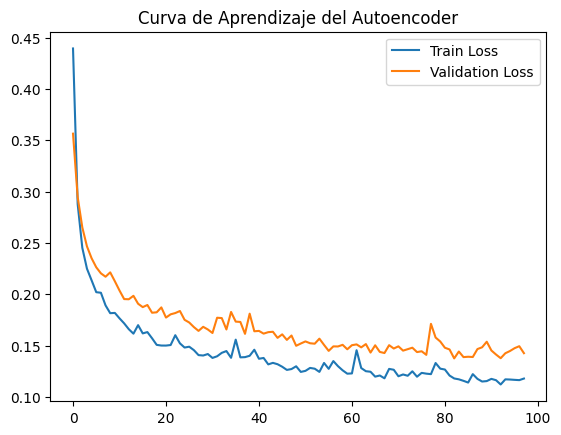

In [75]:
set_seed(RANDOM_SEED)

train_loader, val_loader = get_dataloaders(X_train_std, y_train, X_val_std, y_val)
input_dimension = X_train_std.shape[1] 
latent_dimension = k_90 # Uso el mismo numero de componentes que para PCA para comparar resultados

autoencoder = AE(input_dim=input_dimension, latent_dim=latent_dimension, dropout_p=0.01)

trainer = Trainer(autoencoder, train_loader, val_loader, lr=0.001)
loss_history, val_loss_history = trainer.train(early_stopping=True, patience=15, epochs=200)

mejor_val_loss = min(val_loss_history)
mejor_epoch = val_loss_history.index(mejor_val_loss) + 1

print("-" * 50)
print(f"Entrenamiento finalizado.")
print(f"El modelo restauró sus pesos a la epoch {mejor_epoch}.")
print(f"Validation Loss final retenida: {mejor_val_loss:.4f}")
print("-" * 50)

# Grafico de la learning curve del autoencoder
plt.plot(loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Validation Loss')
plt.legend()
plt.title('Curva de Aprendizaje del Autoencoder')
plt.show()

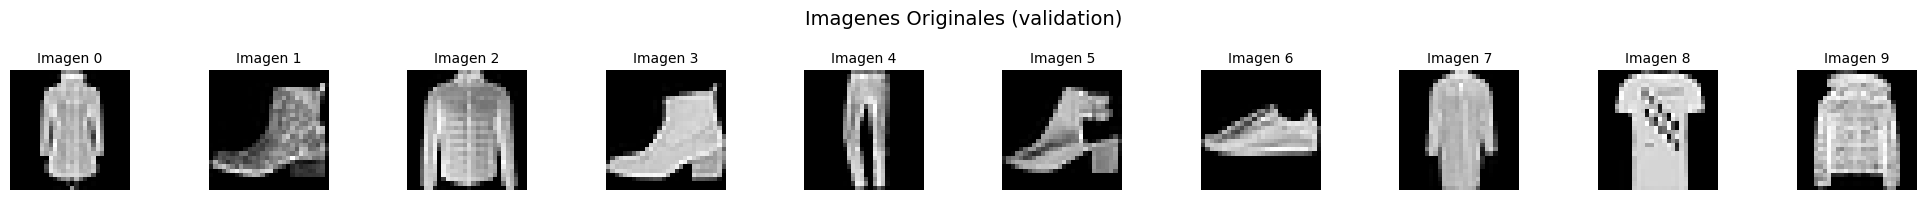

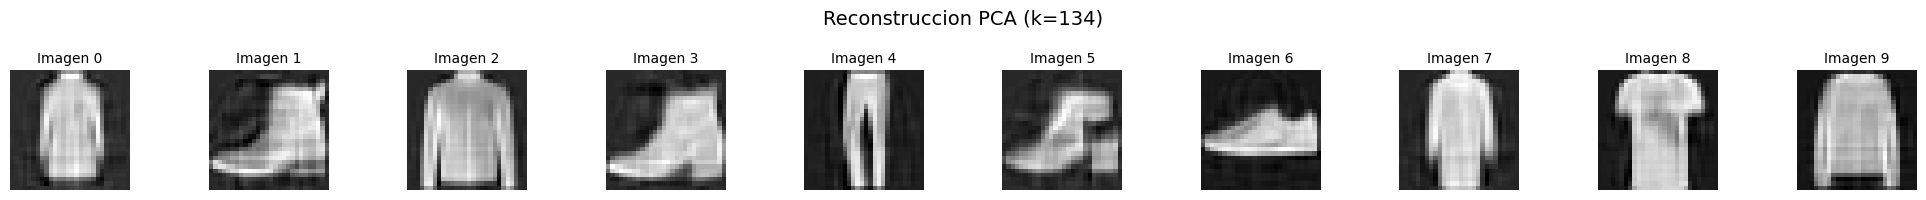

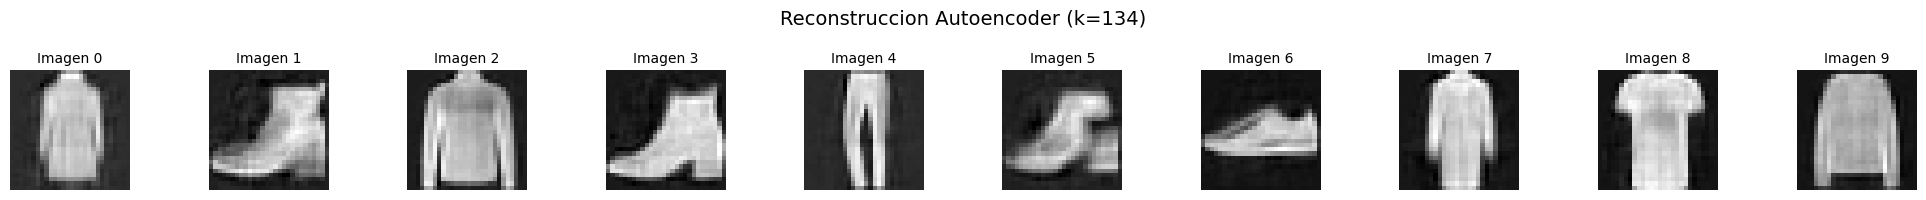

In [84]:
np.random.seed(RANDOM_SEED) 
indices = np.random.choice(len(X_val), 10, replace=False)

# muestras aleaotrias de validation para comparar las reconstrucciones
X_sample_std = X_val_std[indices]
X_sample_original = X_val[indices]

# reconstruccion con PCA
X_sample_pca_latente = pca_transform(X_sample_std, components_train, k_90)
X_sample_pca_rec = pca_inverse_transform(X_sample_pca_latente, components_train, k_90, mean_train, std_train)

# reconstruccion con Autoencoder
X_sample_ae_std_rec = autoencoder.reconstruct(X_sample_std)
X_sample_ae_rec = (X_sample_ae_std_rec * std_train) + mean_train

print_images(10, X_sample_original, random_seed=RANDOM_SEED, title="Imagenes Originales (validation)", cols=10)
print_images(10, X_sample_pca_rec, random_seed=RANDOM_SEED, title=f"Reconstruccion PCA (k={k_90})", cols=10)
print_images(10, X_sample_ae_rec, random_seed=RANDOM_SEED, title=f"Reconstruccion Autoencoder (k={latent_dimension})", cols=10)


In [87]:
# dimension latente de PCA
X_train_pca = pca_transform(X_train_std, components_train, k_90)
X_val_pca = pca_transform(X_val_std, components_train, k_90)
print(f"Forma de X_train_pca: {X_train_pca.shape}")
print(f"Forma de X_val_pca: {X_val_pca.shape}\n")

# dimension latente del Autoencoder
X_train_ae = autoencoder.get_latent_features(X_train_std)
X_val_ae = autoencoder.get_latent_features(X_val_std)
print(f"Forma de X_train_ae: {X_train_ae.shape}")
print(f"Forma de X_val_ae: {X_val_ae.shape}")

Forma de X_train_pca: (20000, 134)
Forma de X_val_pca: (5000, 134)

Forma de X_train_ae: (20000, 134)
Forma de X_val_ae: (5000, 134)
